c:\PromSec\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


hi


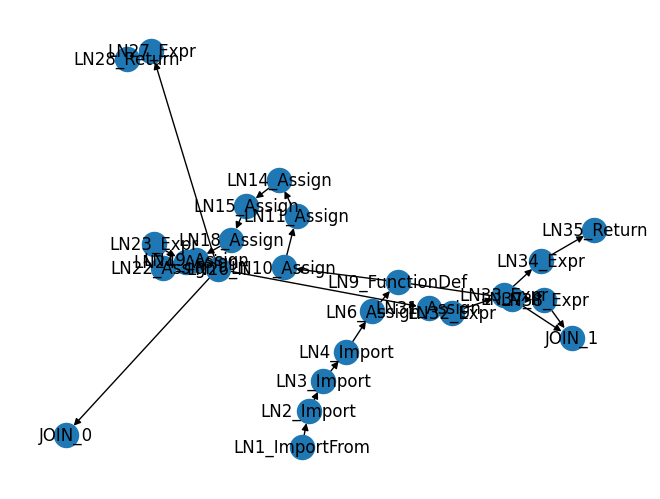

27
[[0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
  1.    0.033]
 [0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    1.
  1.    0.92 ]
 [0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    1.
  1.    0.92 ]
 [0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    1.
  1.    0.92 ]
 [0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    1.
  1.    0.198]
 [1.    0.    0.    0.    0.    0.    0.    0.    0.    1.    1.    1.
  2.    0.923]
 [0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    1.    1.
  1.    0.198]
 [0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    1.    1.
  1.    0.198]
 [0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    1.
  1.    0.198]
 [0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    1.    1.
  1.    0.198]
 [0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    1.    1.
  1.    0.198]
 [0.    0.    0.    0.    0.    0.    0.    0.    0

c:\PromSec\utils_new.py:182: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:256.)
  edge_index = torch.tensor(adj_matrix.nonzero(), dtype=torch.long)


In [1]:
import os
import ast
import copy
import json
import re
import shutil
import datetime
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import subprocess
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch_geometric.data import Data
from torch_geometric.nn import GraphConv
from torch.nn import BCEWithLogitsLoss
from sklearn.preprocessing import LabelEncoder
from prettytable import PrettyTable
from openai import OpenAI
from torch_geometric.data import Data
from staticfg import CFGBuilder

from utils_new import generate_graph_from_ast, get_node_features, adjacency_matrix_to_edge_index
from utils_new import calculate_similarity1, get_tokens, NormalizeNames, get_normalized_ast
from utils_new import ast_structure, calculate_similarity2, calculate_similarity
from utils_new import extract_graph_from_pyg_data, load_original_code, compare_asts
from utils_new import calc_diff, VCS, run_bandit, generate_cfg_from_code, build_cfg_from_ast


print("hi")
file_path = 'Testing_DS\\test_file0.py'  # Replace with your Python file path
cfg = generate_cfg_from_code(file_path)
nx.draw(cfg, with_labels=True)
plt.show()
#cfg1 = CFGBuilder().build_from_file('test_file0', 'Testing_DS\\test_file0.py')
#cfg1.build_visual('exampleCFG', 'pdf')
#print("Nodes in CFG:", cfg.nodes(data=True))
#print("Edges in CFG:", cfg.edges())
print(cfg.number_of_nodes())

training_data = []

node_features = [get_node_features(cfg, node) for node in cfg.nodes()]
training_data.append({'graph': cfg, 'features': node_features})


# Create a label encoder
label_encoder = LabelEncoder()

# Create a list to store PyG Data objects
pyg_data_list_test = []

# Process each graph in the training data
for graph_data in training_data:
    graph = graph_data['graph']
    adj_matrix = nx.adjacency_matrix(graph).toarray()

    # Convert node features to a proper shape
    node_features = np.array(graph_data['features'])
    num_nodes = len(node_features)
    node_features = node_features.reshape(num_nodes, -1)  # Reshape to a 2D array

    # Flatten and encode labels
    x_list = [item for sublist in node_features for item in sublist]
    print(node_features)
    encoded_labels = label_encoder.fit_transform(x_list)
    #print(encoded_labels)
    encoded_labels = torch.tensor(encoded_labels, dtype=torch.float32)  # Use float32 for node features
    encoded_labels = encoded_labels.unsqueeze(1)

    # Create a PyG Data object
    edge_index = adjacency_matrix_to_edge_index(adj_matrix)
    print(edge_index)
    #print(encoded_labels)
    #pyg_data_test = Data(x=encoded_labels, edge_index=edge_index)
    x = torch.tensor(node_features, dtype=torch.float32)
    pyg_data_test = Data(x=x, edge_index=edge_index)
    pyg_data_list_test.append(pyg_data_test)
